In [12]:
# load mentions

import pandas as pd
import json

pop_file = "../../data/mentions/narrative_mentions.jsonl"

records = []

with open(pop_file, "r", encoding="utf-8") as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            print(f"Skipping malformed line in {pop_file}")

mentions_df = pd.DataFrame(records)

print(mentions_df.shape)
print(mentions_df.columns)


(537645, 15)
Index(['paperId', 'doi', 'oa_id', 'text_type', 'text_cleaned', 'match_type',
       'matched_seq', 'matched_char_start', 'matched_char_end', 'sentence_pos',
       'pos', 'id', 'context_token_ids', 'context_n_tokens',
       'matched_token_indices'],
      dtype='str')


In [2]:
24690/311686

0.07921433750633651

In [3]:
19857/24690

0.8042527339003646

# add matched sequence count

In [16]:
mentions_df["matched_seq"].value_counts()

matched_seq
narrative             304594
narratives            194892
narration               6958
narrator                6044
narratively             3910
                       ...  
worldviewnarrative         1
protonarrative             1
pilgrimnarratives          1
coherentnarratives         1
cardsnarratives            1
Name: count, Length: 711, dtype: int64

In [17]:
mentions_df["match_type"].value_counts()

match_type
full_match    505940
stem_match     31705
Name: count, dtype: int64

In [18]:
mentions_df[mentions_df["match_type"] == "stem_match"]["matched_seq"].value_counts()

matched_seq
narration           6958
narrator            6044
narratology         2382
narrating           2329
narrated            2314
                    ... 
narratiivinen          1
narratologischer       1
narratologen           1
narratrice             1
alternarration         1
Name: count, Length: 320, dtype: int64

In [19]:
mentions_df[mentions_df["match_type"] == "full_match"]["matched_seq"].value_counts()

matched_seq
narrative             304594
narratives            194892
narratively             3910
metanarrative            451
counternarratives        390
                       ...  
worldviewnarrative         1
protonarrative             1
pilgrimnarratives          1
coherentnarratives         1
cardsnarratives            1
Name: count, Length: 391, dtype: int64

# prep the latex

In [20]:
stem_df = (
    mentions_df[mentions_df["match_type"] == "stem_match"]["matched_seq"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"matched_seq": "matched_seq"})
)

stem_df["rank"] = range(1, len(stem_df) + 1)


full_df = (
    mentions_df[mentions_df["match_type"] == "full_match"]["matched_seq"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"matched_seq": "matched_seq"})
)

full_df["rank"] = range(1, len(full_df) + 1)

In [32]:
matched_df = stem_df.merge(
    full_df,
    on="rank",
    suffixes=("_stem", "_full")
)

matched_df.head(25)

,matched_seq_stem,count_stem,rank,matched_seq_full,count_full
0,narration,6958,1,narrative,304594
1,narrator,6044,2,narratives,194892
2,narratology,2382,3,narratively,3910
3,narrating,2329,4,metanarrative,451
4,narrated,2314,5,counternarratives,390
5,narrators,1983,6,metanarratives,313
6,narrate,1660,7,counternarrative,243
7,narrativity,1480,8,nonnarrative,102
8,narratological,1286,9,antenarrative,90
9,narrations,969,10,ludonarrative,65


In [25]:
latex = (
    matched_df.head(20)
    .loc[:, ["rank", "matched_seq_stem", "count_stem",
             "matched_seq_full", "count_full"]]
    .to_latex(
        index=False,
        column_format="rll|ll",
        header=["Rank", "Stem", "Count", "Full", "Count"],
    )
)

print(latex)

\begin{tabular}{rll|ll}
\toprule
Rank & Stem & Count & Full & Count \\
\midrule
1 & narration & 6958 & narrative & 304594 \\
2 & narrator & 6044 & narratives & 194892 \\
3 & narratology & 2382 & narratively & 3910 \\
4 & narrating & 2329 & metanarrative & 451 \\
5 & narrated & 2314 & counternarratives & 390 \\
6 & narrators & 1983 & metanarratives & 313 \\
7 & narrate & 1660 & counternarrative & 243 \\
8 & narrativity & 1480 & nonnarrative & 102 \\
9 & narratological & 1286 & antenarrative & 90 \\
10 & narrations & 969 & ludonarrative & 65 \\
11 & narrates & 779 & antenarratives & 44 \\
12 & narrativization & 413 & narrativeness & 38 \\
13 & narrativa & 385 & micronarratives & 37 \\
14 & narrativas & 322 & econarrative & 19 \\
15 & narrativizing & 174 & narrativen & 18 \\
16 & narratorial & 167 & narrativeqa & 18 \\
17 & narrativized & 156 & ofnarrative & 17 \\
18 & narratologists & 128 & hypernarrative & 16 \\
19 & narrativize & 120 & nnarrative & 12 \\
20 & narratee & 78 & narrativer

# check terms

In [39]:
mentions_df[(mentions_df["matched_seq"] == "ludonarrative") & (mentions_df.text_type == "title")]["doi"].unique()

<ArrowStringArray>
[   '10.4108/eai.15-9-2023.2340881',             '10.54941/ahfe1002709',
      '10.1007/978-3-030-04028-4_7',        '10.1177/16094069251390161',
     '10.1007/978-3-319-99426-0_10',            '10.14746/hl.2023.16.6',
      '10.1007/978-3-030-37983-4_1',            '10.31237/osf.io/uep74',
               '10.61827/m1yk-vafg',      '10.1007/978-3-030-28176-2_5',
    '10.21184/jkeia.2020.7.14.5.59',     '10.1016/J.ENTCOM.2019.100304',
        '10.32920/ifmj.v5i1-2.2399',             '10.1386/jgvw_00050_1',
                '10.7939/R30Z7196H', '10.37948/ensemble-2021-0301-a018']
Length: 16, dtype: str

In [51]:
mentions_df[(mentions_df["matched_seq"] == "narrativen")].text_cleaned#.iloc[2]#["doi"].unique()

90514     alles eine frage der perspektive – zur sogenan...
133678    anhand einer komparativen analyse von serbien ...
133679    für die analyse der struktur und der politisch...
133680    für die analyse der struktur und der politisch...
177543    morphologische verbfehler in elizitierten narr...
203061    einfluss des bildaufbaus in narrativen auf die...
290288    anhand einer komparativen analyse von serbien ...
290289    für die analyse der struktur und der politisch...
290290    für die analyse der struktur und der politisch...
310574    manifestationen der ideologiekritik in politis...
385470    konjunkte partizipien in der erzählung des ein...
390266    es wird gezeigt, wie die erzählerische komplex...
394780    der aufsatz bietet eine kritische untersuchung...
401856    anhand einer komparativen analyse von serbien ...
401857    für die analyse der struktur und der politisch...
401858    für die analyse der struktur und der politisch...
450403    basierend auf einer narrativen

In [53]:
mentions_df[(mentions_df["matched_seq"] == "narrativer")].text_cleaned

3801      „aufgeblähte zeit“ in narrativer lyrik – yakam...
24086     materiale for analyse er en barnehagelærers na...
68409     i dette ‘singulariteternes samfund’ spiller ku...
89984     narrativer i islamisk stats propagandamagasin,...
106538    narrativer fra ledere i kulturdag - et samarbe...
182449    artiklen omhandler narrativer, der blev formet...
182450    der bliver set nærmere på hvornår, hvordan og ...
231269    biographische real-fiktion als paradigma narra...
348311    in diesem beitrag wird argumentiert, dass das ...
394101             kønslige narrativer i performancekunsten
441370    den store ånd eller de små spøgelser – om kapi...
456579    everyman og superman. litterære og videnskabel...
Name: text_cleaned, dtype: str

In [54]:
mentions_df[(mentions_df["matched_seq"] == "ofnarrative")].text_cleaned

78864     stacy s. klein rutgers university elizabeth ed...
87294     she asserts that "post-modern" implies the fol...
105987    s c h o p e n university of nevada, reno "they...
132562    2 the nature ofnarrative (new york 1966) 181, ...
145009    we also find familiar stories, patterns ofnarr...
146566       an exploration ofnarrative and cultural space.
172445    chaucer and the imagery ofnarrative is an impo...
219992    i propose, in the following pages, to describe...
222318    universityofyork richard walsh everyday saints...
233845    this study was designed to improve students’ r...
270598    conversely, in some instances the names ofcano...
336144    the chronotope is the place where the knots of...
351270    the concept ofnarrative identity, albeit comin...
365346    havely might have said more about boccaccio's ...
397438    in short order, historiography and romance bec...
402029    tracing a gradual diminution ofnarrative autho...
407160    university of exeter luciano p

In [55]:
mentions_df[(mentions_df["matched_seq"] == "nnarrative")].text_cleaned

1708      while&#13;\nbioethicists often rely on biofutu...
105223    in response to new circumstances, the sotl com...
139049    the purpose of this research are to reveal to ...
139051    the findings show that blending mimind and wha...
139052    both applications can help the students to mak...
161092    i then employed collaborative autobiographical...
175235    it combines&#13;\nnarrative synthesis and meta...
283247    while the meaning of the concept is scarcely r...
285774    this report describes the joint research and p...
397460    an analysis of the songs depicts the differenc...
427234    a critical review on the papers on the subject...
470939    &#13;\n&#13;\nnarrative theory explores the re...
Name: text_cleaned, dtype: str

In [59]:
mentions_df.paperId.unique()

<ArrowStringArray>
['0000278bfcd5dfc1d586156ccff16e168f238e83',
 '4aae5a329915daacf79c4354ec5c72d136424348',
 '4aaeb618b4e06b682c54f3db0eace3690b07c01a',
 '4aaf4dfb89a21da3056618c21f92feb93abc3b40',
 '4aaf8289a6d32eefa9cb14263e63bf92379b5432',
 '4aafb522d20f570211324f4054761f146da80800',
 '4aafc3cee9e4cfc2f87eb77443bab01588f2b605',
 '4ab00a958374e43e8d7d1d110bab77e09356d61e',
 '4ab01a952e961ed26efbd6f60898fbd20ec722f2',
 '4ab037d2e21879ac96c6c5c544d0aa8f442316ef',
 ...
 'dd8b5f26fd40db00cfb75c07c4bb19288dfb7090',
 'dd8c01ff55c42f8eb4ca0ad54a4ddb15caf4db88',
 'dd8c0aaad36cfeddcd0e1d67a868957f77cdc8ad',
 'dd8c4fd083a0764c67a9946d2962d11bc18a48fc',
 'dd8c948e4ab0f59a438957eff4f94536579c5492',
 'dd8cdaf8fc3d1d14ecb82af966577e7262172bd0',
 'dd8d475ab113e0b002b3f72b7f8414ec6b56c88f',
 'dd8dbf481a15c7522f03d1ebcd59cb8c94862659',
 'dd8e32e0385085d3b09a77ebfcd98ee1c7284930',
 'dd8e7f6574ff79914cec9b69441f887f018dd959']
Length: 286996, dtype: str

In [58]:
mentions_df[(mentions_df["matched_seq"] == "narrative") | (mentions_df["matched_seq"] == "narratives")].paperId.unique()

<ArrowStringArray>
['0000278bfcd5dfc1d586156ccff16e168f238e83',
 '4aae5a329915daacf79c4354ec5c72d136424348',
 '4aaeb618b4e06b682c54f3db0eace3690b07c01a',
 '4aaf4dfb89a21da3056618c21f92feb93abc3b40',
 '4aaf8289a6d32eefa9cb14263e63bf92379b5432',
 '4aafb522d20f570211324f4054761f146da80800',
 '4aafc3cee9e4cfc2f87eb77443bab01588f2b605',
 '4ab00a958374e43e8d7d1d110bab77e09356d61e',
 '4ab01a952e961ed26efbd6f60898fbd20ec722f2',
 '4ab037d2e21879ac96c6c5c544d0aa8f442316ef',
 ...
 'dd8b5f26fd40db00cfb75c07c4bb19288dfb7090',
 'dd8c01ff55c42f8eb4ca0ad54a4ddb15caf4db88',
 'dd8c0aaad36cfeddcd0e1d67a868957f77cdc8ad',
 'dd8c4fd083a0764c67a9946d2962d11bc18a48fc',
 'dd8c948e4ab0f59a438957eff4f94536579c5492',
 'dd8cdaf8fc3d1d14ecb82af966577e7262172bd0',
 'dd8d475ab113e0b002b3f72b7f8414ec6b56c88f',
 'dd8dbf481a15c7522f03d1ebcd59cb8c94862659',
 'dd8e32e0385085d3b09a77ebfcd98ee1c7284930',
 'dd8e7f6574ff79914cec9b69441f887f018dd959']
Length: 282806, dtype: str

In [61]:
1-len(mentions_df[(mentions_df["matched_seq"] == "narrative") | (mentions_df["matched_seq"] == "narratives")].paperId.unique())/len(mentions_df.paperId.unique())

0.014599506613332536

# distribution of mentions per paper

In [71]:
distribution = (
    mentions_df[(mentions_df["matched_seq"] == "narrative") | (mentions_df["matched_seq"] == "narratives")]["paperId"]
    .value_counts()
    .value_counts()
    .sort_index()
    .rename_axis("n_rows")
    .rename("n_papers")
    .reset_index()
)

distribution

,n_rows,n_papers
0,1,190146
1,2,46100
2,3,19360
3,4,10416
4,5,6091
5,6,3725
6,7,2364
7,8,1572
8,9,948
9,10,648


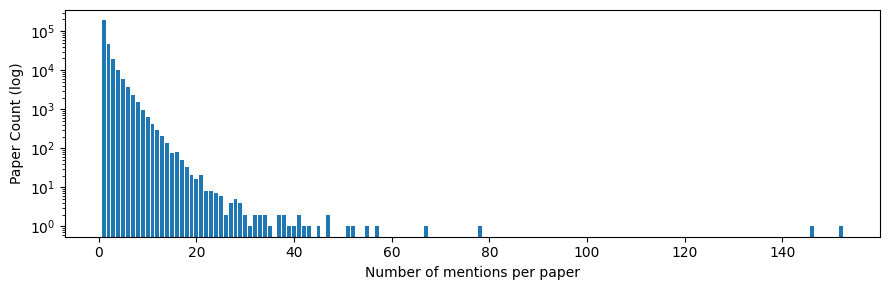

In [73]:
import matplotlib.pyplot as plt

counts = mentions_df[(mentions_df["matched_seq"] == "narrative") | (mentions_df["matched_seq"] == "narratives")]["paperId"].value_counts()

plt.figure(figsize=(9, 3))

plt.hist(
    mentions_df[(mentions_df["matched_seq"] == "narrative") | (mentions_df["matched_seq"] == "narratives")]["paperId"].value_counts(),
    bins=range(1, mentions_df[(mentions_df["matched_seq"] == "narrative") | (mentions_df["matched_seq"] == "narratives")]["paperId"].value_counts().max() + 2),#range(1, counts.max() + 6, 5),#range(1, mentions_df["paperId"].value_counts().max() + 2),
    align="left",
    rwidth=0.8,
)

plt.xlabel("Number of mentions per paper")
plt.ylabel("Paper Count (log)")
#plt.title("Distribution of mentions per paperId")
plt.yscale("log")

plt.tight_layout()
plt.show()